# Module 3.18 — Turbulence Models

**Goal:** Understand how $k$–$\varepsilon$, $k$–$\omega$ SST, and wall functions work, when to use each, and how to implement a simple turbulence model in Python.

**Models covered:**
- Mixing-length (0-equation, recap)
- $k$–$\varepsilon$ (2-equation, standard)
- $k$–$\omega$ SST (2-equation, industry standard)
- Wall functions (engineering shortcut)
- Spalart–Allmaras (1-equation, aerodynamics)

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_banded

## 1. Eddy Viscosity — Quick Recap

From 3.17, the Boussinesq hypothesis closes the Reynolds stress with one scalar $\nu_t$:

$$-\overline{u_i' u_j'} = 2\,\nu_t\,\bar{S}_{ij} - \tfrac{2}{3}k\,\delta_{ij}$$

**Every 2-equation model computes $\nu_t$ differently.** The key formula for $k$–$\varepsilon$:

$$\boxed{\nu_t = C_\mu \frac{k^2}{\varepsilon}}$$

| Symbol | Meaning | Units |
|---|---|---|
| $k$ | Turbulent kinetic energy $= \frac{1}{2}\overline{u_i'u_i'}$ | m²/s² |
| $\varepsilon$ | Dissipation rate (energy → heat) | m²/s³ |
| $\nu_t$ | Eddy viscosity | m²/s |
| $C_\mu$ | Model constant = 0.09 | — |

**Physical intuition:** Large $k$ (strong fluctuations) and small $\varepsilon$ (slow decay) → large $\nu_t$ (strong mixing). The ratio $k/\varepsilon$ has units of time — it is the **turbulent time scale** $\tau_t$.

## 2. The $k$–$\varepsilon$ Model

Two coupled transport equations — one for $k$, one for $\varepsilon$:

### Turbulent Kinetic Energy $k$

$$\frac{\partial k}{\partial t} + \bar{u}_j\frac{\partial k}{\partial x_j} = \underbrace{P_k}_{\text{production}} - \underbrace{\varepsilon}_{\text{dissipation}} + \frac{\partial}{\partial x_j}\!\left[\left(\nu + \frac{\nu_t}{\sigma_k}\right)\frac{\partial k}{\partial x_j}\right]$$

### Dissipation Rate $\varepsilon$

$$\frac{\partial \varepsilon}{\partial t} + \bar{u}_j\frac{\partial \varepsilon}{\partial x_j} = \underbrace{C_{\varepsilon 1}\frac{\varepsilon}{k}P_k}_{\text{production}} - \underbrace{C_{\varepsilon 2}\frac{\varepsilon^2}{k}}_{\text{destruction}} + \frac{\partial}{\partial x_j}\!\left[\left(\nu + \frac{\nu_t}{\sigma_\varepsilon}\right)\frac{\partial \varepsilon}{\partial x_j}\right]$$

### Production term

$$P_k = \nu_t \left|\frac{\partial \bar{u}_i}{\partial x_j} + \frac{\partial \bar{u}_j}{\partial x_i}\right|^2 = 2\,\nu_t\,\bar{S}_{ij}\bar{S}_{ij}$$

Turbulence is produced by **mean flow shear** — the steeper the velocity gradient, the more $k$ is generated.

### Model constants (standard values)

| $C_\mu$ | $C_{\varepsilon 1}$ | $C_{\varepsilon 2}$ | $\sigma_k$ | $\sigma_\varepsilon$ |
|---|---|---|---|---|
| 0.09 | 1.44 | 1.92 | 1.0 | 1.3 |

### Known limitation

$k$–$\varepsilon$ works well **away from walls** (free jets, mixing layers). Near walls, $\varepsilon$ becomes singular as $y \to 0$, requiring either:
- Very fine near-wall mesh with **low-Re damping functions** (expensive)
- **Wall functions** (cheap engineering approximation)

## 3. $k$–$\omega$ SST Model (Menter 1994)

**Motivation:** Replace $\varepsilon$ with $\omega = \varepsilon / (C_\mu k)$ — the **specific dissipation rate**. $\omega$ behaves well at walls ($\omega \to \infty$ as $y \to 0$, but predictably).

**Key idea — blending:**

$$\phi_{\text{SST}} = F_1 \cdot \phi_{k\text{-}\omega} + (1 - F_1) \cdot \phi_{k\text{-}\varepsilon}$$

where $F_1$ is a **blending function** that depends on wall distance $y$:

$$F_1 = \tanh\!\left(\left[\min\!\left(\max\!\left(\frac{\sqrt{k}}{C_\mu\,\omega\,y},\ \frac{500\nu}{\omega y^2}\right),\ \frac{4\rho\sigma_{\omega 2}k}{\text{CD}_{k\omega}\,y^2}\right)\right]^4\right)$$

- $F_1 = 1$ near the wall → uses $k$–$\omega$ (accurate near walls)
- $F_1 = 0$ in the free stream → uses $k$–$\varepsilon$ (accurate away from walls)

### Additional feature: stress limiter

SST also limits the eddy viscosity using the strain rate $S = |2\bar{S}_{ij}\bar{S}_{ij}|^{1/2}$:

$$\nu_t = \frac{a_1 k}{\max(a_1\omega,\ S\,F_2)}$$

This prevents over-production of $\nu_t$ in stagnation regions (e.g. in front of a cylinder), which is a well-known failure mode of standard $k$–$\varepsilon$.

### Why SST dominates industry

| Property | $k$–$\varepsilon$ | $k$–$\omega$ SST |
|---|---|---|
| Near-wall accuracy | Poor (singular $\varepsilon$) | ✅ Good (well-posed $\omega$) |
| Free-stream accuracy | ✅ Good | ✅ Good (blends to $k$–$\varepsilon$) |
| Separated flows | Poor | ✅ Better (stress limiter) |
| Stagnation regions | Over-predicts $\nu_t$ | ✅ Corrected |
| Default in OpenFOAM/Fluent | — | ✅ Yes |

## 4. Wall Functions

Resolving the viscous sublayer ($y^+ < 5$) requires very thin cells — expensive at high Re. Wall functions skip the sublayer by placing the first cell in the **log-law region** ($y^+ \approx 30$–$100$) and using the log-law analytically.

### Standard wall function for velocity

Given the first cell centre at $y_1$ with mean velocity $\bar{u}_1$, compute friction velocity $u_\tau$:

$$u^+ = \frac{\bar{u}_1}{u_\tau} = \frac{1}{\kappa}\ln(y_1^+) + B$$

Solve iteratively for $u_\tau$, then the wall shear stress:

$$\tau_w = \rho\,u_\tau^2$$

### Wall boundary conditions for $k$ and $\varepsilon$

At the wall-adjacent cell (in log-law region), $k$ and $\varepsilon$ are set by equilibrium assumptions:

$$k_w = \frac{u_\tau^2}{\sqrt{C_\mu}} \qquad \varepsilon_w = \frac{u_\tau^3}{\kappa\,y_1}$$

### $y^+$ requirements

| Mesh type | First cell $y^+$ | Model |
|---|---|---|
| Low-Re mesh | $y^+ < 1$ | Resolve sublayer (k-ω or damped k-ε) |
| High-Re mesh (wall functions) | $30 < y^+ < 100$ | Skip sublayer analytically |
| Automatic wall treatment (SST) | any $y^+$ | Blends between the two |

> **Rule of thumb:** For industrial RANS, target $y^+ \approx 1$ with SST, or $y^+ \approx 50$ with wall functions. Never put the first cell in the buffer layer ($5 < y^+ < 30$) — accuracy is worst there.

## 5. Spalart–Allmaras Model (1992)

A **1-equation** model that solves a transport equation directly for a modified eddy viscosity $\tilde{\nu}$:

$$\frac{\partial \tilde{\nu}}{\partial t} + \bar{u}_j\frac{\partial \tilde{\nu}}{\partial x_j} = c_{b1}\tilde{S}\tilde{\nu} - c_{w1}f_w\left(\frac{\tilde{\nu}}{d}\right)^2 + \frac{1}{\sigma}\nabla\cdot\left[(\nu + \tilde{\nu})\nabla\tilde{\nu}\right]$$

where $d$ is wall distance. The actual eddy viscosity $\nu_t = \tilde{\nu}\,f_{v1}$ with near-wall damping.

| Property | Spalart–Allmaras |
|---|---|
| Equations | 1 (transport for $\tilde{\nu}$) |
| Best for | External aerodynamics, attached boundary layers |
| Weakness | Poor for separated flows, jets, wakes |
| Used in | NASA, aerospace industry, DES |
| OpenFOAM | `SpalartAllmaras` |

## 6. Implementation — Turbulent Channel Flow with $k$–$\varepsilon$

**Setup:** Fully-developed turbulent channel flow between two parallel walls.

- Domain: $y \in [0, H]$, $H = 1$ m (half-channel, symmetric)
- Mean flow in $x$: driven by pressure gradient $dP/dx = -1$ Pa/m
- Boundary conditions at wall ($y=0$): $\bar{u}=0$, $k=0$, $\varepsilon = 2\nu(\partial\sqrt{k}/\partial y)^2$
- At centreline ($y=H$): symmetry $\partial\bar{u}/\partial y = 0$, $\partial k/\partial y = 0$, $\partial\varepsilon/\partial y = 0$

We solve the 1D RANS + $k$–$\varepsilon$ equations in steady state:

$$\frac{d}{dy}\left[(\nu + \nu_t)\frac{d\bar{u}}{dy}\right] = \frac{1}{\rho}\frac{dP}{dx}$$

$$\frac{d}{dy}\left[(\nu + \nu_t/\sigma_k)\frac{dk}{dy}\right] + P_k - \varepsilon = 0$$

$$\frac{d}{dy}\left[(\nu + \nu_t/\sigma_\varepsilon)\frac{d\varepsilon}{dy}\right] + C_{\varepsilon1}\frac{\varepsilon}{k}P_k - C_{\varepsilon2}\frac{\varepsilon^2}{k} = 0$$

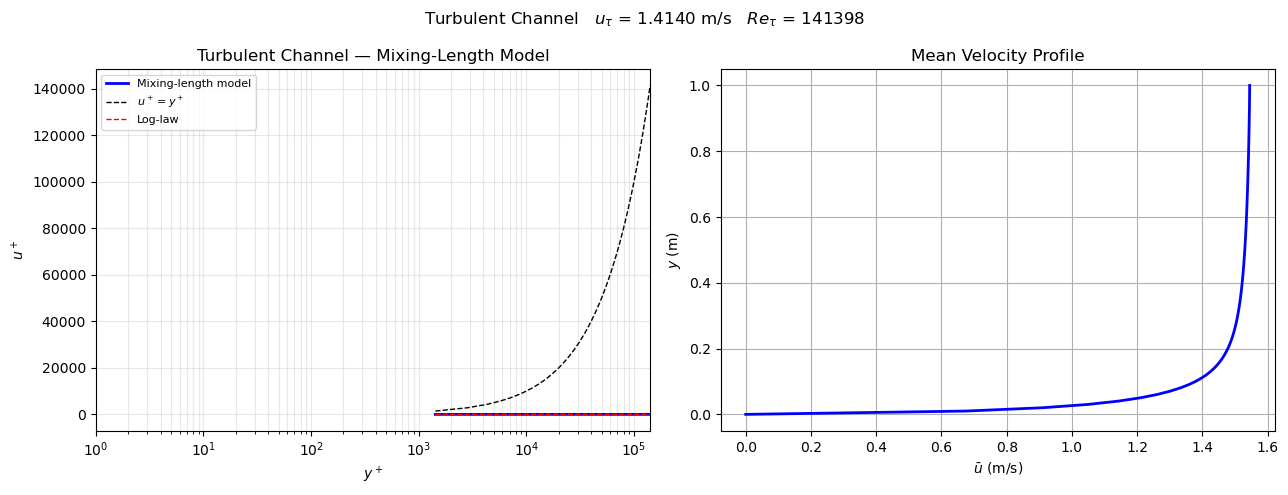

Friction velocity  u_tau  = 1.41398 m/s
Friction Reynolds  Re_tau = 141397.7
Max y+             = 141397.7


In [4]:
# k-epsilon model constants
C_mu    = 0.09
C_e1    = 1.44
C_e2    = 1.92
sigma_k = 1.0
sigma_e = 1.3
kappa   = 0.41    # von Karman constant

# Flow parameters
nu      = 1e-5    # kinematic viscosity (m^2/s)
dPdx    = -1.0    # pressure gradient (Pa/m)
rho     = 1.0     # density (kg/m^3)
H       = 1.0     # half-channel height (m)

# Grid
N  = 100
y  = np.linspace(0, H, N)
dy = y[1] - y[0]

def mixing_length(y, u_tau, nu):
    y_plus = y * u_tau / nu
    return kappa * y * (1 - np.exp(-y_plus / 26.0))

def solve_channel(nu_eff, dPdx, rho, dy, N):
    """Solve d/dy[(nu_eff)*du/dy] = dPdx/rho using banded tridiagonal."""
    # Face-averaged diffusion coefficients — N-1 faces between N nodes
    nu_face = 0.5 * (nu_eff[:-1] + nu_eff[1:])   # shape (N-1,)

    upper = nu_face / dy**2                         # shape (N-1,)
    lower = nu_face / dy**2                         # shape (N-1,)
    diag  = np.zeros(N)
    diag[1:-1] = -(nu_face[:-1] + nu_face[1:]) / dy**2   # interior nodes
    rhs = np.full(N, dPdx / rho)

    # Wall BC: u[0] = 0 (Dirichlet)
    upper_a = upper.copy();  upper_a[0] = 0.0
    diag[0]  = 1.0;          rhs[0]     = 0.0

    # Symmetry BC at y=H: du/dy=0 (ghost cell: u[N]=u[N-1])
    lower_a = lower.copy()
    diag[-1] = -nu_face[-1] / dy**2
    rhs[-1]  = dPdx / rho

    ab = np.zeros((3, N))
    ab[0, 1:]  = upper_a   # upper diagonal: (N-1,) into (N-1,) ✓
    ab[1, :]   = diag      # main diagonal:  (N,)   into (N,)   ✓
    ab[2, :-1] = lower_a   # lower diagonal: (N-1,) into (N-1,) ✓
    return solve_banded((1, 1), ab, rhs)

# Iterative solve: mixing-length model
u_bar = np.zeros(N)
u_tau = 0.05

for _ in range(500):
    lm     = mixing_length(y, u_tau, nu)
    S      = np.gradient(u_bar, y)
    nu_t   = lm**2 * np.abs(S)
    nu_eff = nu + nu_t

    u_bar  = solve_channel(nu_eff, dPdx, rho, dy, N)

    tau_w  = rho * nu_eff[1] * (u_bar[1] - u_bar[0]) / dy
    u_tau  = np.sqrt(abs(tau_w) / rho)

# Wall units
y_plus = y * u_tau / nu

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.semilogx(y_plus[1:], u_bar[1:]/u_tau,                        'b-',  lw=2,   label='Mixing-length model')
ax1.semilogx(y_plus[1:], y_plus[1:],                              'k--', lw=1,   label='$u^+=y^+$')
ax1.semilogx(y_plus[1:], (1/kappa)*np.log(y_plus[1:]) + 5.2,     'r--', lw=1,   label='Log-law')
ax1.set_xlabel('$y^+$'); ax1.set_ylabel('$u^+$')
ax1.set_title('Turbulent Channel — Mixing-Length Model')
ax1.legend(fontsize=8); ax1.grid(True, which='both', alpha=0.3)
ax1.set_xlim([1, y_plus[-1]])

ax2.plot(u_bar, y, 'b-', lw=2)
ax2.set_xlabel('$\\bar{u}$ (m/s)'); ax2.set_ylabel('$y$ (m)')
ax2.set_title('Mean Velocity Profile')
ax2.grid(True)

plt.suptitle(f'Turbulent Channel   $u_\\tau$ = {u_tau:.4f} m/s   $Re_\\tau$ = {u_tau*H/nu:.0f}', fontsize=12)
plt.tight_layout()
plt.show()

print(f'Friction velocity  u_tau  = {u_tau:.5f} m/s')
print(f'Friction Reynolds  Re_tau = {u_tau*H/nu:.1f}')
print(f'Max y+             = {y_plus[-1]:.1f}')

## 7. Which Model for Which Problem?

| Flow type | Recommended model | Why |
|---|---|---|
| External aero, attached BL | Spalart–Allmaras or $k$–$\omega$ SST | Clean wall BL, mild separation |
| Internal pipe/channel flow | $k$–$\varepsilon$ with wall functions | Away from walls, cheap |
| Separated flow (stall, BL separation) | $k$–$\omega$ SST | Stress limiter prevents over-production |
| Free jets, mixing layers | $k$–$\varepsilon$ | No walls, $k$–$\varepsilon$ calibrated here |
| Swirling flows, combustion | RSM (Reynolds Stress Model) | Boussinesq fails for strong curvature |
| LES available | LES with Smagorinsky SGS | Captures unsteady large eddies |

### When does Boussinesq fail?

The Boussinesq hypothesis assumes turbulence is **isotropic** (equal in all directions). This fails when:

- Strong curvature (curved ducts, cyclones)
- Strong rotation (turbomachinery)
- Strong adverse pressure gradient (separation)
- Impingement flows (jet hitting a wall)

In these cases, use **RSM** (solves all 6 Reynolds stress components) or **LES**.

## Summary

| Model | Equations | $\nu_t$ from | Best for |
|---|---|---|---|
| Mixing-length | 0 | $\ell_m^2|d\bar{u}/dy|$ | Simple shear flows |
| Spalart–Allmaras | 1 | $\tilde{\nu}$ transport | Aerodynamic BLs |
| $k$–$\varepsilon$ | 2 | $C_\mu k^2/\varepsilon$ | Free-stream, jets |
| $k$–$\omega$ SST | 2 | Blended near-wall/free | **Industry default** |
| RSM | 7 | Direct $\overline{u_i'u_j'}$ | Complex geometry |

**Key formula chain for $k$–$\varepsilon$:**

$$P_k = \nu_t|\nabla\bar{u}|^2 \longrightarrow k,\varepsilon \text{ equations} \longrightarrow \nu_t = C_\mu\frac{k^2}{\varepsilon} \longrightarrow \text{RANS momentum}$$

**Next:** Module 3.19 — Mesh Generation (structured vs unstructured, quality metrics)